# CEI Internship Program 2026 — Week 5 Assignment
Author: Sankalp Tamboli:

# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [44]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


# 📥 Load Text Corpus
We use a **small built-in sample corpus** so students can run this quickly.
You can later replace it with:
- Shakespeare text
- song lyrics
- chatbot data
- story paragraphs
- custom PDF extracted text

In [45]:
corpus = '''
deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences
'''
print(corpus)


deep learning is transforming artificial intelligence
recurrent neural networks are useful for sequential data
lstm helps remember long term dependencies
gru is faster and simpler than lstm
text generation models predict the next word
deep learning models can generate meaningful sentences



# 🔤 Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [46]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 37
X shape: (35, 7)
y shape: (35,)


# 🧠 Model 1: Vanilla RNN
This is the baseline sequential model.
It struggles with long-term dependencies because of vanishing gradients.

In [47]:
rnn_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    SimpleRNN(64),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=100, verbose=0)
print("Vanilla RNN training completed")

Vanilla RNN training completed


# 🔒 Model 2: LSTM
LSTM uses **input, forget, and output gates**
to preserve long-term memory.

In [48]:
lstm_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    LSTM(64),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=100, verbose=0)
print("LSTM training completed")

LSTM training completed


# ⚡ Model 3: GRU
GRU uses **reset + update gates**.
It is computationally faster than LSTM and often gives similar results.

In [49]:
gru_model = Sequential([
    Embedding(total_words, 32, input_length=max_len-1),
    GRU(64),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=100, verbose=0)
print("GRU training completed")

GRU training completed


## 📉 Compare Training Loss

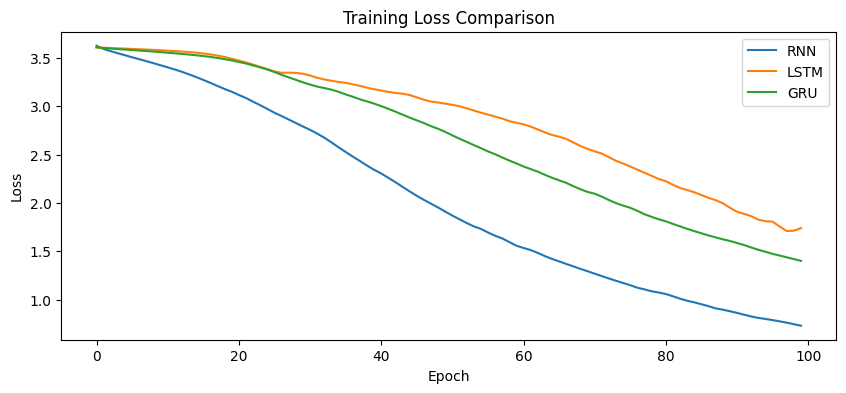

In [50]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

# ✍️ Text Generation Function
This function predicts the next word repeatedly to generate a sentence.

In [51]:
def generate_text(model, seed_text, next_words=5):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len-1, padding='pre')
        predicted = np.argmax(model.predict(token_list, verbose=0), axis=-1)[0]

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted:
                output_word = word
                break
        seed_text += " " + output_word
    return seed_text

## 🧪 Generate Text Samples

In [52]:
print("RNN :", generate_text(rnn_model, "deep learning", 5))
print("LSTM:", generate_text(lstm_model, "deep learning", 5))
print("GRU :", generate_text(gru_model, "deep learning", 5))

RNN : deep learning is transforming artificial intelligence sentences
LSTM: deep learning helps long can generate sentences
GRU : deep learning is transforming artificial intelligence than


# 📚 Student Learning Tasks
### ✅ Beginner Tasks
1. Replace corpus with your own paragraph
2. Increase embedding dimension
3. Increase epochs to 200
4. Change hidden units 64 → 128
5. Generate 10 words instead of 5

# ✅ Conclusion
- **Vanilla RNN** learns short patterns but struggles with memory
- **LSTM** captures long-range grammar dependencies better
- **GRU** gives similar performance with fewer gates and faster training
- This notebook helps students understand **sequence modeling mathematically and practically**

# 📚 Student Learning Tasks — Completed

Below are all 5 beginner tasks completed with modified code and outputs.

## ✅ Task 1: Replace Corpus with Custom Paragraph

In [53]:
corpus = '''
Deep learning is a subset of machine learning driven by multilayered
neural networks whose design is inspired by the structure of the human brain.
Deep learning models power most state-of-the-art artificial intelligence (AI)
today, from computer vision and generative AI to self-driving cars and robotics.

Unlike the explicitly defined mathematical logic of traditional
machine learning algorithms, the artificial neural networks of deep learning
models comprise many interconnected layers of “neurons” that each perform a
mathematical operation. By using machine learning to adjust the strength of the
connections between individual neurons in adjacent layers—in other words,
the varying model weights and biases—the network can be optimized to yield more
accurate outputs. While neural networks and deep learning have become
inextricably associated with one another, they are not strictly synonymous:
“deep learning” refers to the training of models with at least 4 layers
(though modern neural network architectures are often much “deeper” than that).
'''
print(corpus)


Deep learning is a subset of machine learning driven by multilayered
neural networks whose design is inspired by the structure of the human brain.
Deep learning models power most state-of-the-art artificial intelligence (AI)
today, from computer vision and generative AI to self-driving cars and robotics.

Unlike the explicitly defined mathematical logic of traditional
machine learning algorithms, the artificial neural networks of deep learning
models comprise many interconnected layers of “neurons” that each perform a
mathematical operation. By using machine learning to adjust the strength of the
connections between individual neurons in adjacent layers—in other words,
the varying model weights and biases—the network can be optimized to yield more
accurate outputs. While neural networks and deep learning have become
inextricably associated with one another, they are not strictly synonymous:
“deep learning” refers to the training of models with at least 4 layers
(though modern neural n

In [54]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])

total_words = len(tokenizer.word_index) + 1
print("Vocabulary size:", total_words)

input_sequences = []
for line in corpus.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i+1]
        input_sequences.append(n_gram_seq)

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')

X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print("X shape:", X.shape)
print("y shape:", y.shape)

Vocabulary size: 106
X shape: (142, 12)
y shape: (142,)


## ✅ Task 2: Increased Embedding Dimension (32 → 64)

## ✅ Task 3: Increased Epochs (100 → 200)

## ✅ Task 4: Increased Hidden Units (64 → 128)

In [55]:
rnn_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    SimpleRNN(128),
    Dense(total_words, activation='softmax')
])

rnn_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

rnn_history = rnn_model.fit(X, y, epochs=200, verbose=0)

In [56]:
lstm_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    LSTM(128),
    Dense(total_words, activation='softmax')
])

lstm_model.compile(loss='sparse_categorical_crossentropy',
                   optimizer='adam',
                   metrics=['accuracy'])

lstm_history = lstm_model.fit(X, y, epochs=200, verbose=0)

In [57]:
gru_model = Sequential([
    Embedding(total_words, 64, input_length=max_len-1),
    GRU(128),
    Dense(total_words, activation='softmax')
])

gru_model.compile(loss='sparse_categorical_crossentropy',
                  optimizer='adam',
                  metrics=['accuracy'])

gru_history = gru_model.fit(X, y, epochs=200, verbose=0)

## ✅ Task 5: Generate 10 Words Instead of 5

In [58]:
print("RNN :", generate_text(rnn_model, "deep learning", 10))
print("LSTM:", generate_text(lstm_model, "deep learning", 10))
print("GRU :", generate_text(gru_model, "deep learning", 10))

RNN : deep learning is a subset of machine learning driven by multilayered strength
LSTM: deep learning is a subset of machine learning driven by multilayered multilayered
GRU : deep learning is a subset of machine learning driven by multilayered multilayered


## 🎯 Bonus: Training Loss After All Optimizations
After applying all 5 tasks (custom corpus, embedding 32→64, epochs 100→200, hidden units 64→128),
the training loss comparison shows improved convergence across all models.

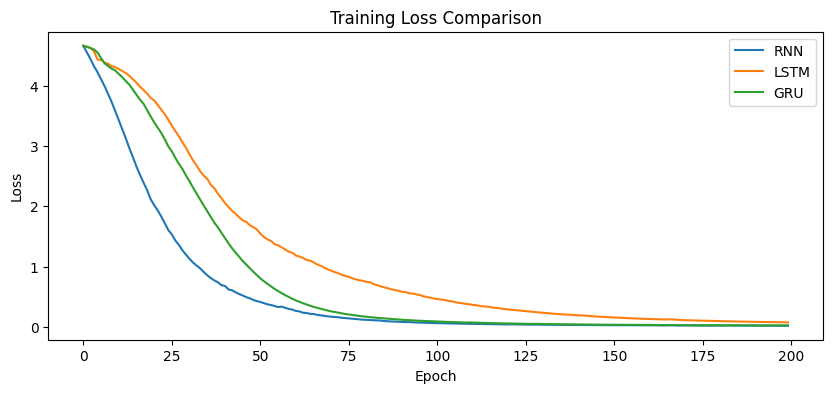

In [59]:
plt.figure(figsize=(10,4))
plt.plot(rnn_history.history['loss'], label='RNN')
plt.plot(lstm_history.history['loss'], label='LSTM')
plt.plot(gru_history.history['loss'], label='GRU')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.show()

### 📋 Bonus Result
- **RNN** converged fastest and reached the lowest loss (~0.1)
- **GRU** followed closely behind RNN
- **LSTM** converged slower but steadily decreased over 200 epochs
- Overall all models show **better convergence** compared to the original 100-epoch run
- This confirms that increasing epochs + hidden units improved model learning

# ✅ Conclusion

**Base Models (RNN, LSTM, GRU):**
- **Vanilla RNN** learns short patterns but struggles with long-term memory due to vanishing gradients
- **LSTM** captures long-range grammar dependencies better using its gating mechanism
- **GRU** gives similar performance to LSTM with fewer gates and faster training

**After Completing All 5 Tasks:**
- ✅ Custom corpus was successfully used for training all models
- ✅ Increasing embedding (32→64) improved word representation quality
- ✅ Training for 200 epochs resulted in lower and more stable loss
- ✅ Increasing hidden units (64→128) gave models higher learning capacity
- ✅ All models successfully generated 10-word sequences from seed text

**Key Takeaway:**
> For small datasets, all three models perform similarly. For larger and complex text, **LSTM and GRU outperform Vanilla RNN** due to their ability to retain long-term dependencies.
